#Image classification with K-nearest neighbor
In this notebook, we will work with image classification using the K-nearest neighbor (KNN) algorithm, which we’ve just learned about. The purpose of this exercise is to learn how to develop and train classification models, particularly for images.
The K-nearest neighbor algorithm has some obvious weaknesses when it comes to image classification. It is one of the earliest examples of machine learning, introduced by Evelyn Fix and Joseph Hodges in 1951. Nevertheless, it serves as a good introduction to machine learning models and how to properly develop them. Later, when we explore neural networks, this notebook will also highlight the advancements that have occurred in the field of image classification.


#Dataset
The dataset used in this notebook is the "BloodMNIST" dataset, which comes from the [MedMNIST databasen](https://medmnist.com/)

#Description from the original source:
The BloodMNIST dataset is based on a collection of individual normal cells captured from individuals without infection, hematologic or oncologic disease, and free of any pharmacological treatment at the time of blood collection. It contains a total of 17,092 images and is organized into 8 classes. The source dataset is split with a ratio of 7:1:2 into training, validation, and test sets

The images are available in various resolutions: 28x28, 64x64, 128x128, and 224x224, with 3 channels (RGB). In this notebook, we will work with images in 28x28x3 resolution. The 8 different classes are:

['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


AThese classes are represented categorically with the following values

[0, 1, 2, 3, 4, 5, 6, 7]

Below, the dataset is downloaded, imported, and split into separate training, validation (tuning), and test sets, and some examples are illustrated.


In [2]:
%pip install medmnist
import medmnist

from medmnist import BloodMNIST
trainDataset = BloodMNIST(split="train", download=True,size=28)
valDataset = BloodMNIST(split="val", download=True,size=28)
testDataset = BloodMNIST(split="test", download=True,size=28)


Note: you may need to restart the kernel to use updated packages.


Training data:
Images: (11959, 28, 28, 3), Labels: (11959, 1)
Validation data:
Images: (1712, 28, 28, 3), Labels: (1712, 1)
Test data:
Images: (3421, 28, 28, 3), Labels: (3421, 1)


plot some examples:
Class: 0, class name: basophil. Number of training samples: 852
Class: 1, class name: eosinophil. Number of training samples: 2181
Class: 2, class name: erythroblast. Number of training samples: 1085
Class: 3, class name: immature granulocytes(myelocytes, metamyelocytes and promyelocytes). Number of training samples: 2026
Class: 4, class name: lymphocyte. Number of training samples: 849
Class: 5, class name: monocyte. Number of training samples: 993
Class: 6, class name: neutrophil. Number of training samples: 2330
Class: 7, class name: platelet. Number of training samples: 1643


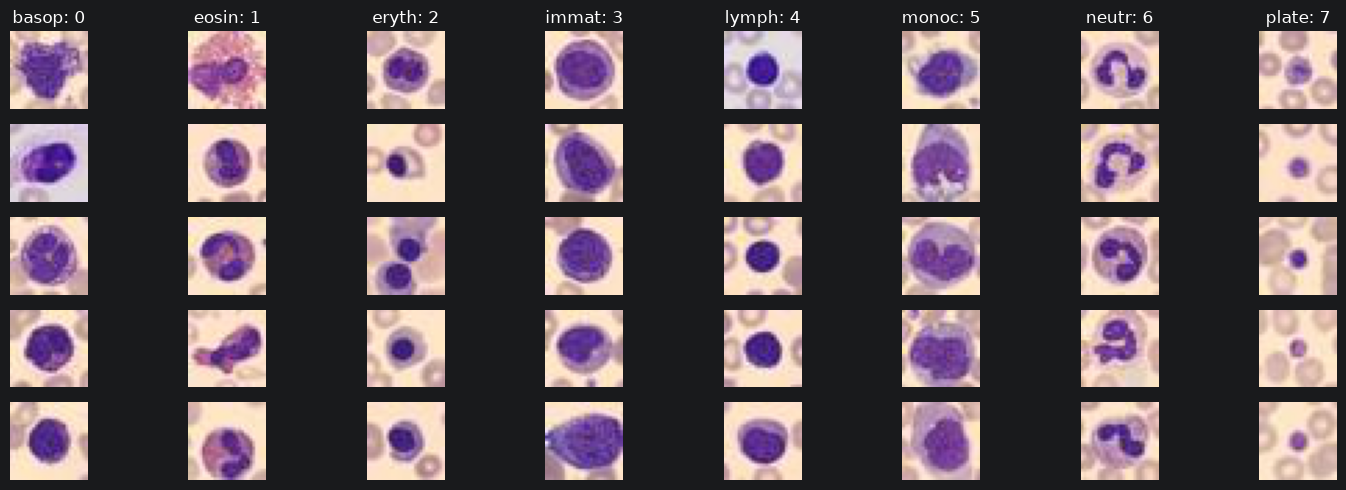

In [3]:

trainImages,trainLabels,trainInfo = trainDataset.__dict__['imgs'],trainDataset.__dict__['labels'],trainDataset.__dict__['info']['label']


print('Training data:')
print(f'Images: {trainImages.shape}, Labels: {trainLabels.shape}')


valImages,valLabels = valDataset.__dict__['imgs'],valDataset.__dict__['labels']
print('Validation data:')
print(f'Images: {valImages.shape}, Labels: {valLabels.shape}')

testImages,testLabels = testDataset.__dict__['imgs'],testDataset.__dict__['labels']
print('Test data:')
print(f'Images: {testImages.shape}, Labels: {testLabels.shape}')

import matplotlib.pyplot as plt
import random

print('\n')
print('plot some examples:')

random.seed(42)
fig, axes = plt.subplots(5, len(trainInfo), figsize=(15, 5))

for class_,name in trainInfo.items():
    print(f'Class: {class_}, class name: {name}. Number of training samples: {len(trainLabels[trainLabels==int(class_)])}')
    # Get indices of all images belonging to class i
    class_indices = [idx for idx, label in enumerate(trainLabels) if int(class_) == label]
    # Randomly select 5 indices
    selected_indices = random.sample(class_indices, 5)
    for j, idx in enumerate(selected_indices):
        image, label = trainImages[idx],trainLabels[idx]
        axes[j, int(class_)].imshow(image, cmap='gray')
        axes[j, int(class_)].axis('off')
        if j == 0:
            axes[j, int(class_)].set_title(f'{name[:5]}: {class_}')

plt.tight_layout()
plt.show()

As shown above, we are working with a dataset that is relatively homogeneous in terms of the appearance of the different classes and is imbalanced. This means, for example, that there are significantly more samples of the neutrophil class than of the basophil class. Both of these factors will make solving the classification problem challenging, not only in this notebook but also when working with other models.
Below, we perform some preprocessing of the data to make it more manageable in this notebook.

In [4]:
import numpy as np

#set random seed for reproducibility
np.random.seed(0)

#Shuffle the data
randomize = np.arange(trainImages.shape[0])
np.random.shuffle(randomize)

X_train = trainImages[randomize]
y_train = trainLabels[randomize].flatten()

randomizeVal = np.arange(valImages.shape[0])
X_val = valImages[randomizeVal]
y_val = valLabels[randomizeVal].flatten()


# Subsample the data for more efficient code execution in this exercise
num_training = 5000
mask = list(range(num_training))

X_train = X_train[mask]
y_train = y_train[mask]

print('first 10 examples in train: ',y_train[:10])

num_val = 500
mask = list(range(num_val))
X_val = X_val[mask]
y_val = y_val[mask]

print('first 10 examples in val: ',y_val[:10])

# Reshape the image data into rows for effecient distance calculation
#(vi tager billedet med dimensioner 28x28x3 og strækker det ud til en vektor med længden 28*28*3 = 2352)
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
print(f'New train shape: {X_train.shape}')
print(f'New val shape: {X_val.shape}')


first 10 examples in train:  [1 0 2 7 7 4 3 0 4 7]
first 10 examples in val:  [4 0 7 6 1 6 1 7 6 5]
New train shape: (5000, 2352)
New val shape: (500, 2352)


#K-nearest neighbor algorithm
Below, the model itself is implemented. A k-Nearest Neighbors (kNN) model is a "lazy learner", meaning the training function essentially just stores the data (training images + labels) for reference.
An implementation of the kNN algorithm would typically include:
A "training" function where the model simply stores the training data for comparison.
A function to calculate the distance from test/validation examples to training examples using a given metric (e.g., Euclidean distance).
A function to make predictions based on the k nearest neighbors.
This is represented in pseudocode below.



    class  KNearestNeighbor:

      Method __init__():
          Initialize the classifier

      Method train(X_train, y_train):
          Store the training data X_train and labels y_train

      Method calculate_distances(X_test):
          Initialize distance matrix
          For each test point in X_test:
              For each training point in X_train:
                  Compute the distance between the test point and the training point
                  Store the result in the distance matrix
          Return the distance matrix

      Method predict(X_test, k):
          Calculate distances between X_test and X_train
          Initialize predicted labels array
          For each test point:
              Find the k nearest neighbors using the distance matrix
              Determine the most common label among the k nearest neighbors
              Store the predicted label
          Return the predicted labels array

kNN algoritmen har som udgangspunkt to hyperparametre: K og afstandsmetrikken som eksempelvis L1 og L2. Overvej om implementering ud over parameteren K og skal have en parameter for afstand i.e. L2/L1, for at se hvordan det påvirker klassificeringen. Implementeringen skal laves kun vha. Python/Numpy.

Det kan være en rimeligt omfattende opgave så det er helt OK at søge efter implementeringer online eller bruge chat-gpt, co-pilot etc.

Tip! I pseudokoden ovenfor er der lagt op til at afstanden beregnes ved at loop over de enkelte trænings og test eksempler. Dette tager al for lang tid i praksis og det er derfor mere optimalt at vektorisere operationen.

In [1]:
class KNearestNeighbor:
    """A vectorized k-Nearest Neighbor classifier supporting L1 and L2 distance."""

    def __init__(self):
        self.X_train = None
        self.y_train = None

    def train(self, X_train, y_train):
        # kNN is a "lazy learner": training just means storing the data
        self.X_train = X_train
        self.y_train = y_train

    def calculate_distances(self, X_test, dist_metric='L2'):
        num_test = X_test.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.zeros((num_test, num_train))

        if dist_metric == 'L2':
            # ||a - b||^2 = ||a||^2 - 2 a.b + ||b||^2, fully vectorized (no loops)
            test_sq = np.sum(X_test ** 2, axis=1).reshape(num_test, 1)
            train_sq = np.sum(self.X_train ** 2, axis=1).reshape(1, num_train)
            cross_term = X_test @ self.X_train.T
            dists = np.sqrt(np.maximum(test_sq - 2 * cross_term + train_sq, 0))
        elif dist_metric == 'L1':
            # L1 has no dot-product shortcut like L2. Looping over test points only
            # (not train points) keeps this vectorized enough while avoiding a
            # (num_test x num_train x num_features) array that would blow up memory.
            for i in range(num_test):
                dists[i, :] = np.sum(np.abs(self.X_train - X_test[i, :]), axis=1)
        else:
            raise ValueError(f"Unknown distance metric: {dist_metric}. Use 'L1' or 'L2'.")

        return dists

    def predict(self, X_test, k=1, dist_metric='L2'):
        dists = self.calculate_distances(X_test, dist_metric=dist_metric)
        num_test = dists.shape[0]
        y_pred = np.zeros(num_test, dtype=self.y_train.dtype)

        for i in range(num_test):
            # Indices of the k closest training points for this test point
            nearest_idx = np.argsort(dists[i])[:k]
            nearest_labels = self.y_train[nearest_idx]
            # Majority vote among the k nearest labels
            values, counts = np.unique(nearest_labels, return_counts=True)
            y_pred[i] = values[np.argmax(counts)]

        return y_pred, dists


##Test implementation

After implementing the algorithm, we want to test whether it works by first training it on the training set and then evaluating it on the validation set. We can start by trying a random value for k and calculating its accuracy.

    knn = KNearestNeighbor()

    knn.train(X_train,y_train)

    #try using different values for k e.g. k = 5
    

    predictions = knn.predict(X_val,k=k)


    num_correct = sum(predictions == y_val)


    knn accuracy for k =  num_correct/num_y_val * 100



In [5]:
knn = KNearestNeighbor()
knn.train(X_train, y_train)

k = 5
predictions, _ = knn.predict(X_val, k=k, dist_metric='L2')

num_correct = np.sum(predictions == y_val)
accuracy = num_correct / y_val.shape[0] * 100
print(f'knn accuracy for k = {k} (L2 distance): {num_correct}/{y_val.shape[0]} correct => {accuracy:.2f}%')


knn accuracy for k = 5 (L2 distance): 71/500 correct => 14.20%


##"Sanity check"
To verify whether the algorithm behaves as expected, we could plot some examples from the validation dataset alongside their nearest neighbors to see if the results look reasonable. (Example from my own implementation.)

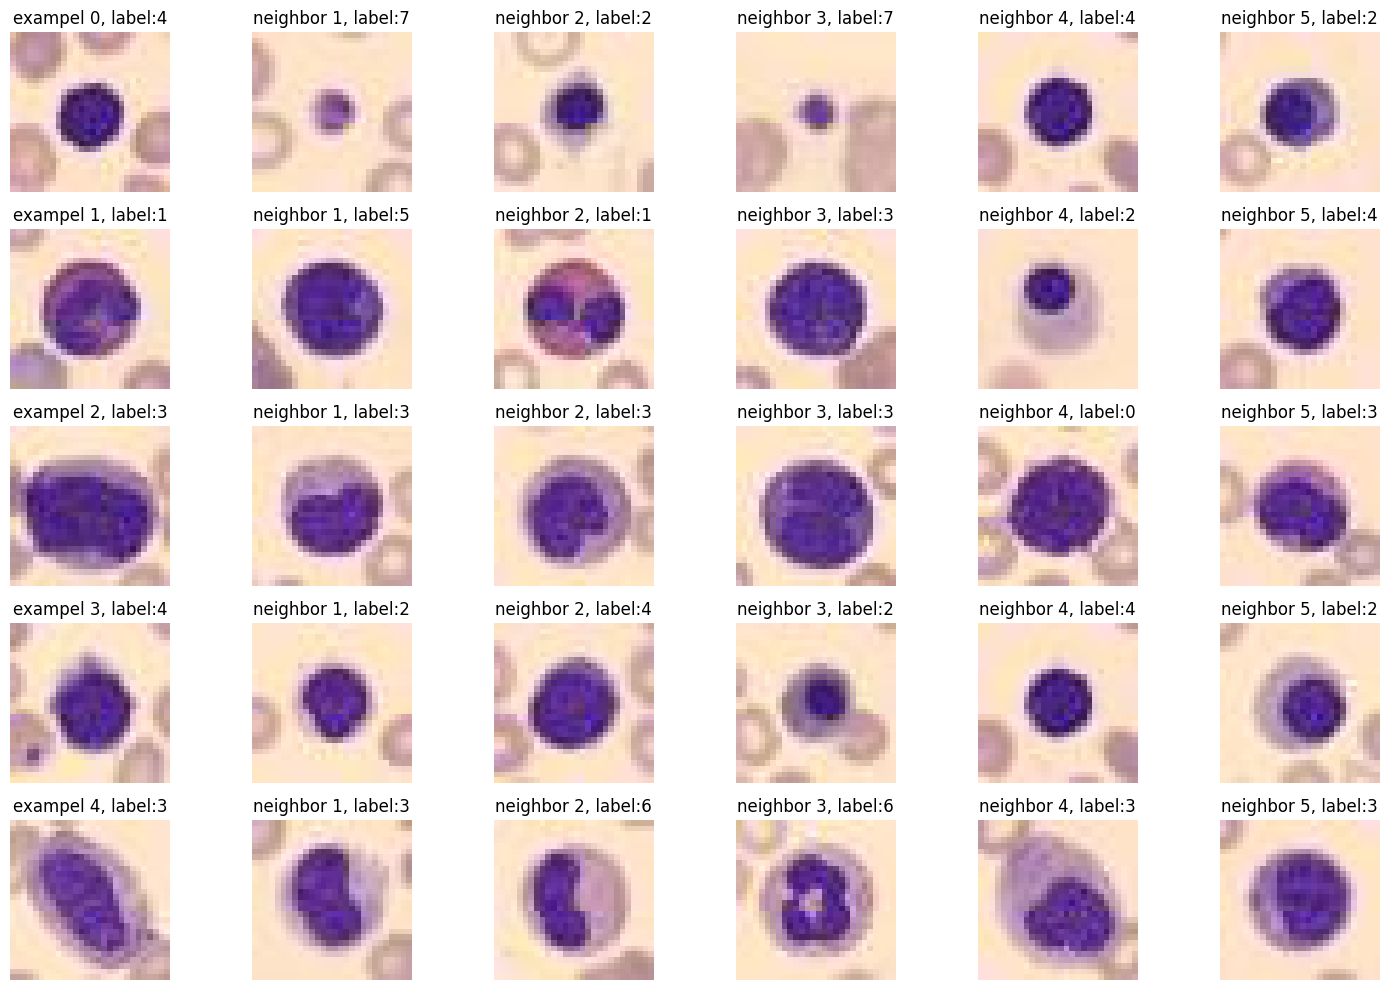

##Optimizing the model (Hyperparameter tuning)
We have now reached the stage where we have our model and need to find the best configuration. The nearest neighbor algorithm is a non-parametric model, meaning it doesn’t "learn" in the traditional sense. However, we can optimize it through hyperparameter tuning, which is essentially a method of finding the best settings by trial and error.

*   Distance function (L1/L2)
*   Number of neighbors (K)

The dataset is already divided into separate training, validation, and test sets. Once the best configuration is found using the validation set, it should then be tested on a separate test set.

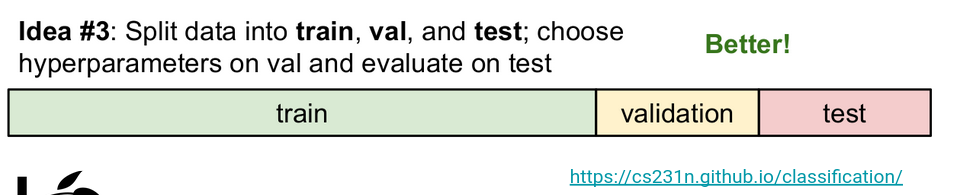



#Tip!
Hyperparameter tuning can take a long time with many values, e.g.,

neighbors = [1, 3, 5, 7, 13, 21, 33, 45, 55, 67, 79, 91, 111, 131, 149, 167, 193, 201].

To save time, start with a few widely spaced values and then narrow down the search based on the results.
Search for the optimal value of k (and possibly the distance metric) by looping through the values as shown above.




    knn = KNearestNeighbor()

    knn.train(X_train,y_train)


    neighbors = [1,5,13,33,67,79,91,131,167,201]


    for k_n in neighbors:
      predictions,_ = knn.predict(X_val,k=k_n)
      num_correct = sum(predictions==y_val)

      k_accuracy = (num_correct/y_val.shape[0])*100


dist=L1, k=  1 -> accuracy: 22.20%
dist=L1, k=  3 -> accuracy: 22.80%
dist=L1, k=  5 -> accuracy: 23.60%
dist=L1, k=  7 -> accuracy: 21.40%
dist=L1, k= 13 -> accuracy: 21.20%
dist=L1, k= 21 -> accuracy: 20.40%
dist=L1, k= 33 -> accuracy: 19.80%
dist=L1, k= 45 -> accuracy: 20.20%
dist=L1, k= 55 -> accuracy: 20.60%
dist=L1, k= 67 -> accuracy: 20.20%
dist=L1, k= 79 -> accuracy: 20.00%
dist=L1, k= 91 -> accuracy: 19.40%
dist=L1, k=111 -> accuracy: 20.00%
dist=L1, k=131 -> accuracy: 19.40%
dist=L1, k=149 -> accuracy: 19.40%
dist=L1, k=167 -> accuracy: 19.20%
dist=L1, k=193 -> accuracy: 18.80%
dist=L1, k=201 -> accuracy: 18.40%
dist=L2, k=  1 -> accuracy: 14.20%
dist=L2, k=  3 -> accuracy: 14.20%
dist=L2, k=  5 -> accuracy: 14.20%
dist=L2, k=  7 -> accuracy: 14.20%
dist=L2, k= 13 -> accuracy: 14.20%
dist=L2, k= 21 -> accuracy: 14.20%
dist=L2, k= 33 -> accuracy: 9.40%
dist=L2, k= 45 -> accuracy: 9.40%
dist=L2, k= 55 -> accuracy: 9.40%
dist=L2, k= 67 -> accuracy: 9.40%
dist=L2, k= 79 -> accura

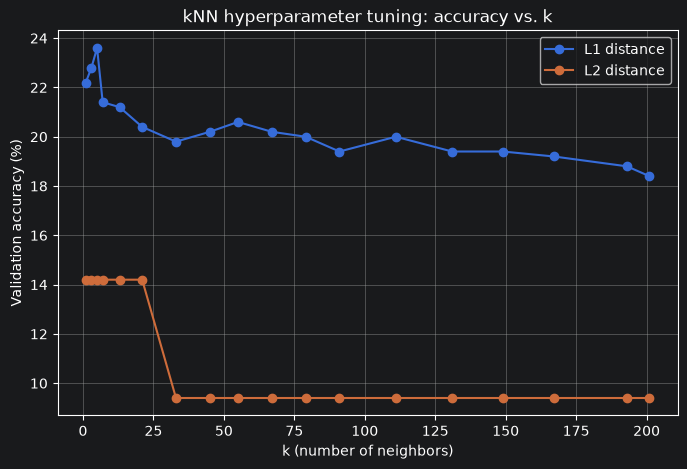

In [6]:
neighbors = [1, 3, 5, 7, 13, 21, 33, 45, 55, 67, 79, 91, 111, 131, 149, 167, 193, 201]
distance_metrics = ['L1', 'L2']

knn = KNearestNeighbor()
knn.train(X_train, y_train)

results = {}  # dist_metric -> list of accuracies (aligned with `neighbors`)

for dist_metric in distance_metrics:
    accuracies = []
    for k_n in neighbors:
        predictions, _ = knn.predict(X_val, k=k_n, dist_metric=dist_metric)
        num_correct = np.sum(predictions == y_val)
        k_accuracy = (num_correct / y_val.shape[0]) * 100
        accuracies.append(k_accuracy)
        print(f'dist={dist_metric}, k={k_n:>3d} -> accuracy: {k_accuracy:.2f}%')
    results[dist_metric] = accuracies

# Find the best (k, distance metric) combination on the validation set
best_metric, best_k, best_acc = None, None, -1
for dist_metric, accuracies in results.items():
    for k_n, acc in zip(neighbors, accuracies):
        if acc > best_acc:
            best_metric, best_k, best_acc = dist_metric, k_n, acc

print(f'\nBest config on validation set: k={best_k}, distance={best_metric}, accuracy={best_acc:.2f}%')

# Plot accuracy vs. k for each distance metric
plt.figure(figsize=(8, 5))
for dist_metric, accuracies in results.items():
    plt.plot(neighbors, accuracies, marker='o', label=f'{dist_metric} distance')

plt.xlabel('k (number of neighbors)')
plt.ylabel('Validation accuracy (%)')
plt.title('kNN hyperparameter tuning: accuracy vs. k')
plt.legend()
plt.grid(True)
plt.show()


Save the results of the hyperparameter search above and plot them similarly to the example below.

(From my implementation.)


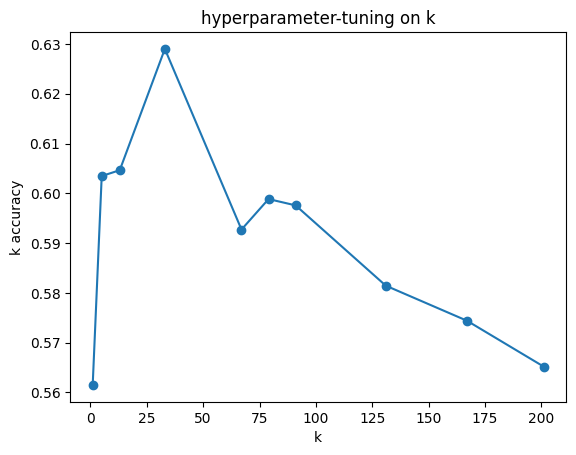

#Test the model
The model is now optimized based on the training and validation sets and is ready to be tested on the test set, which is imported as shown below.


    testDataset = BloodMNIST(split="test", download=True,size=28)
    X_test,y_test = testDataset.__dict__['imgs'],valDataset.__dict__['labels']
    print('Testsdata:')
    print(f'Billeder: {X_test.shape}, Labels: {y_test.shape}')
    X_test = np.reshape(X_test, (X_test.shape[0], -1))
    y_test = y_test.flatten()

    print(X_test.shape,y_test.shape)

In [7]:
# Prepare the test set the same way train/val were prepared earlier
X_test_all = testImages
y_test_all = testLabels.flatten()

# Subsample to avoid crashing Colab; increase this if your environment can handle it
num_test = 1000
mask = list(range(num_test))
X_test = X_test_all[mask]
y_test = y_test_all[mask]

X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(f'Test shape: {X_test.shape}, Labels shape: {y_test.shape}')

# Evaluate on the test set using the best (k, distance metric) found during tuning
predictions, _ = knn.predict(X_test, k=best_k, dist_metric=best_metric)
num_correct = np.sum(predictions == y_test)
test_accuracy = num_correct / y_test.shape[0] * 100

print(f'Test accuracy with k={best_k}, distance={best_metric}: {test_accuracy:.2f}%')


Test shape: (1000, 2352), Labels shape: (1000,)
Test accuracy with k=5, distance=L1: 17.60%


#Note
Google Colab might crash if you test the model on the entire test set at once. To avoid this, you should mask or subsample the test set, similar to how the validation and training sets were handled earlier.

Since we’ve subsampled our data, the optimal value we found for k (or the distance metric) might not be the best possible, as reducing the dataset size rarely leads to better models. While Colab may not handle the full dataset, try increasing the sample size as much as possible and observe how it affects the results.


#That is it!
The results of this task will be reported in Portfolio Assignment 1, along with the results for Assignments 1.2 and 1.3.